# Convolutional Neural Network: 
## Food Recognition

In [54]:
import numpy as np
from pathlib import Path
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from copy import deepcopy

# Progress bar
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms

import tensorboard as tb
from torch.utils.tensorboard import SummaryWriter

In [55]:
%reload_ext tensorboard

## CNN Structure:

In [56]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            nn.Linear(256, 80)
        )

    def forward(self, x):
        return self.net(x)

    @property
    def device(self):
        """
        Returns the device on which the model is. Can be useful in some situations.
        """
        return next(self.parameters()).device

### Seed

In [57]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): # GPU operation have separate seed
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


### Evaluation

In [58]:
def eval_model(model, data_loader):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(model.device)
            targets = targets.to(model.device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

    return total_correct / total_samples

### Analyze Data

Train total items: 30612
Test total items: 7653
Train images: 30612
Test images: 7653


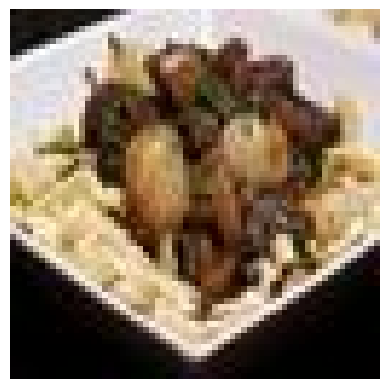

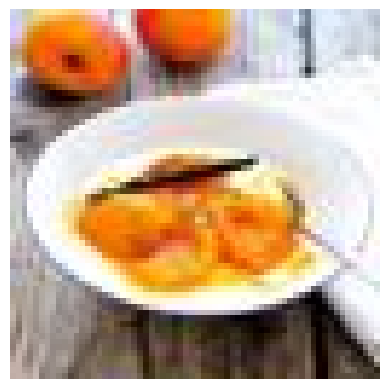

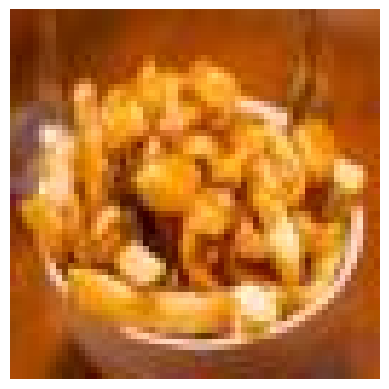

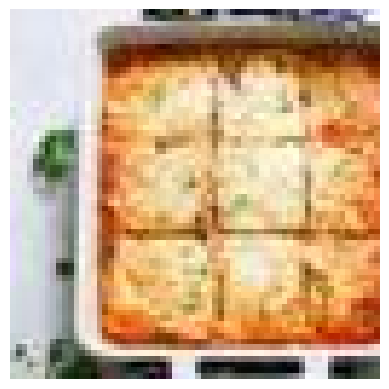

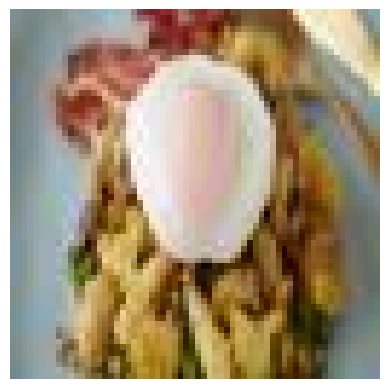

In [59]:
# Creating paths
ROOT = Path("food-recognition-challenge-2026")

TRAIN_DIR = ROOT / "train_set_64"
TEST_DIR  = ROOT / "test_set"
TRAIN_CSV = ROOT / "train_labels.csv"
CLASS_TXT = ROOT / "class_list_food.txt"

# Unpacking the lists of images
train_files = list(TRAIN_DIR.rglob("*.jpg"))
test_files  = list(TEST_DIR.rglob("*"))

# Unpacking the images out of the list
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train_imgs = [p for p in TRAIN_DIR.rglob("*") if p.suffix.lower() in img_exts]
test_imgs  = [p for p in TEST_DIR.rglob("*") if p.suffix.lower() in img_exts]

# Amount of images
print("Train total items:", len(train_files))
print("Test total items:", len(test_files))
print("Train images:", len(train_imgs))
print("Test images:", len(test_imgs))

# Showing images
for i in range(5):
    image = Image.open(train_files[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [60]:
import pandas as pd

# Head of train_labels csv
df = pd.read_csv(TRAIN_CSV)
print(df.head())


      img_name  label
0  train_1.jpg     21
1  train_2.jpg     29
2  train_3.jpg     17
3  train_4.jpg     21
4  train_5.jpg     50


In [61]:
# Creating classes from class_list_food.txt
classes = dict()

with open(CLASS_TXT, 'r') as c:
    for i in c:
        i = i.strip()
        if not i:
            continue

        k, v = i.split(' ', 1)
        classes[k] = v

# Amount of classes
print(len(classes))

80


In [62]:
sizes = []

for p in train_imgs:
    with Image.open(p) as im:
        sizes.append(im.size)         # (width, height)

print("Example sizes:", sizes[:10])

ws = [w for (w,h) in sizes]
hs = [h for (w,h) in sizes]
print("Width min/max:", min(ws), max(ws))
print("Height min/max:", min(hs), max(hs))


Example sizes: [(64, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 64)]
Width min/max: 64 64
Height min/max: 64 64


In [63]:
from sklearn.model_selection import train_test_split

train_label, val_label = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

print(len(train_label), len(val_label))

24489 6123


In [64]:
from torch.utils.data import Dataset
from PIL import Image

class FoodDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]["img_name"]
        label = self.img_labels.iloc[idx]["label"] - 1

        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [65]:
from torchvision import transforms
from torch.utils.data import DataLoader

IMG_SIZE = 64
BATCH_SIZE = 256

train_transform = transforms.Compose([
    transforms.ToTensor(),
])

validation_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = FoodDataset(TRAIN_CSV, TRAIN_DIR, transform=train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

if str(device) == 'cuda':
    train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    )

    validation_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=True,
    )


### Training

In [66]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    seed,
    lr,
    device,
    data_dir="runs/FRC-Challenge",
):
    # Set seed for reproducibility
    set_seed(seed)

    # TensorBoard writer
    writer = SummaryWriter(data_dir)

    # Loss function and optimizer
    loss_module = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Initialize best model tracking
    best_val_acc = -1.0
    best_epoch = -1
    best_model = deepcopy(model)

    # Start training over epochs
    for epoch in tqdm(range(epochs), desc="Epochs"):
        model.train()

        running_loss = 0.0
        total_correct = 0
        total_samples = 0

        scaler = torch.amp.GradScaler(device="cuda")

        # Iterate over training batches
        for inputs, targets in tqdm(train_loader, desc="Training", leave=False):

            # Move batch to device
            if str(device) == 'cuda':
                inputs = inputs.to(device, dtype=torch.float32, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                with torch.amp.autocast(device_type="cuda"):
                    logits = model(inputs)
                    loss = loss_module(logits, targets)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                inputs = inputs.to(device, dtype=torch.float32)
                targets = targets.to(device)

                # Reset gradients
                optimizer.zero_grad()

                # Forward pass
                logits = model(inputs)
                loss = loss_module(logits, targets)

                # Backward pass and parameter update
                loss.backward()
                optimizer.step()

            # Update training statistics
            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

        # Compute epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = total_correct / total_samples

        # Write training metrics to TensorBoard
        writer.add_scalar("Loss/train", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train", epoch_acc, epoch)

        # Evaluate on validation / test set
        val_acc = eval_model(model, val_loader)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        # Print progress
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={epoch_loss:.4f} | "
            f"train_acc={epoch_acc:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model = deepcopy(model)

        # Optional checkpoint saving
        if epoch % 10 == 0:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
            }, "checkpoint.pth")

    # Evaluate the best model final time
    best_test_acc = eval_model(best_model, val_loader)

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Best test accuracy: {best_test_acc:.4f}")

    # Close TensorBoard writer
    writer.close()

    # Save best model weights
    torch.save(best_model.state_dict(), "best_model.pth")

In [67]:
import time
import torch

def profile_one_epoch(model, train_loader, optimizer, loss_module, device):
    model.train()

    data_time = 0.0
    transfer_time = 0.0
    compute_time = 0.0

    end = time.time()

    for inputs, targets in train_loader:
        # tijd sinds vorige iteratie = data loading
        data_time += time.time() - end

        t0 = time.time()
        inputs = inputs.to(device, dtype=torch.float32, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        transfer_time += time.time() - t0

        t1 = time.time()
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_module(outputs, targets)

        loss.backward()
        optimizer.step()

        # wacht tot GPU echt klaar is voor eerlijke timing
        if device.type == "cuda":
            torch.cuda.synchronize()

        compute_time += time.time() - t1
        end = time.time()

    print(f"data loading time: {data_time:.2f}s")
    print(f"transfer time:    {transfer_time:.2f}s")
    print(f"compute time:     {compute_time:.2f}s")

In [68]:
model = CNN().to(device)
loss_module = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
profile_one_epoch(model, train_loader, optimizer, loss_module, device)

train_model(model=model,
            train_loader=train_loader,
            val_loader=validation_loader,
            device=device,
            epochs=100,
            seed=42,
            lr=1e-3)

data loading time: 15.90s
transfer time:    0.01s
compute time:     7.74s


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 1/100 | loss=3.7197 | train_acc=0.1092 | val_acc=0.1138


Training:   0%|          | 0/120 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def predict_test_set(model, test_loader, output_csv="submission.csv"):
    model.eval()

    all_names = []
    all_preds = []

    with torch.no_grad():
        for inputs, names in test_loader:
            inputs = inputs.to(model.device, dtype=torch.float32)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().tolist()

            all_names.extend(names)
            all_preds.extend([p + 1 for p in preds])

    submission_df = pd.DataFrame({
        "img_name": all_names,
        "label": all_preds
    })

    submission_df.to_csv(output_csv, index=False)
    return submission_df

In [ ]:
class FoodTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.transform = transform

        self.image_paths = sorted(
            [p for p in self.img_dir.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path.name

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_dataset = FoodTestDataset(TEST_DIR, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [ ]:
model = CNN().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))

submission_df = predict_test_set(model, test_loader, output_csv="submission.csv")
print(submission_df.head())

C:\Users\antho\AppData\Local\Temp\ipykernel_28288\1287085743.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

PicklingError: Can't pickle <class '__main__.FoodTestDataset'>: it's not the same object as __main__.FoodTestDataset

In [ ]:
%tensorboard --logdir runs/FRC-Challenge